### ***Using LSTM***

### **Environment Setup (Run First)**

In [ ]:
# Upgrade pip and install compatible versions
!pip install --upgrade pip
!pip install numpy==1.26.4 pandas matplotlib scikit-learn
!pip install tensorflow==2.16.1 keras

# Restart runtime to apply changes
import IPython
print("✅ Setup complete! Please RESTART the runtime (Runtime > Restart runtime) and rerun from Cell 2.")
IPython.Application.instance().kernel.do_shutdown(True)

✅ Setup complete! Please RESTART the runtime (Runtime > Restart runtime) and rerun from Cell 2.


{'status': 'ok', 'restart': True}

### **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error
import math

### **Load Dataset**

In [ ]:
# Sample dataset: using a public weather CSV for demo
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url, parse_dates=['Date'])

# Show first few rows
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


### **Visualize Data**

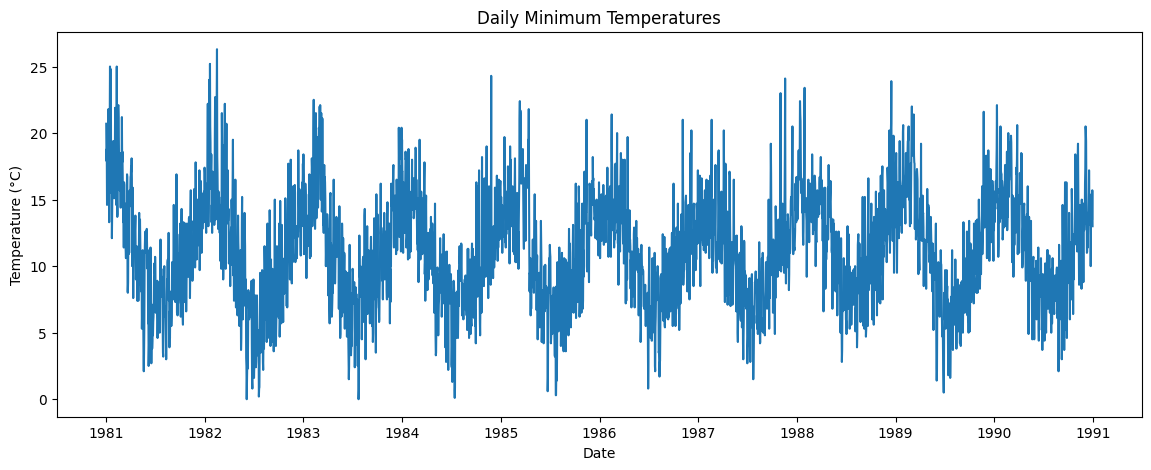

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Temp'])
plt.title('Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

### **Preprocess Data**

In [ ]:
# Use only temperature values
data = df['Temp'].values.reshape(-1, 1)

# Scale data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# Training size (80%)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Function to create sequences
def create_dataset(dataset, time_step=30):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 30
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Reshape for LSTM [samples, time_steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

### **Build LSTM Model**

In [ ]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

### **Train the Model**

In [ ]:
history = model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test))

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0522 - val_loss: 0.0102
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0123 - val_loss: 0.0098
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0120 - val_loss: 0.0096
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0123 - val_loss: 0.0101
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0115 - val_loss: 0.0100
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0116 - val_loss: 0.0088
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0110 - val_loss: 0.0089
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0115 - val_loss: 0.0082
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0100 - val_loss: 0.0081
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0099 - val_loss: 0.0078
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0099 - val_loss: 0.0075
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0

### **Evaluate the Model**

In [ ]:
# Predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform to original scale
train_predict = scaler.inverse_transform(train_predict)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1,1))
test_predict = scaler.inverse_transform(test_predict)
y_test_orig = scaler.inverse_transform(y_test.reshape(-1,1))

# Calculate RMSE
train_rmse = math.sqrt(mean_squared_error(y_train_orig, train_predict))
test_rmse = math.sqrt(mean_squared_error(y_test_orig, test_predict))

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Train RMSE: 2.49
Test RMSE: 2.28


### **Plot Predictions**

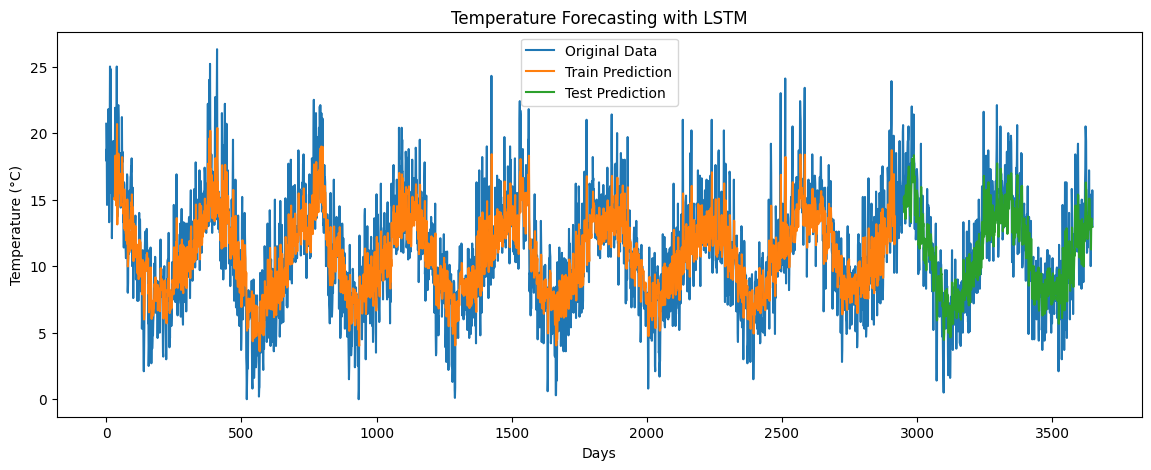

In [ ]:
# Shift predictions for visualization
look_back = time_step
train_plot = np.empty_like(data)
train_plot[:, :] = np.nan
train_plot[look_back:len(train_predict)+look_back, :] = train_predict

test_plot = np.empty_like(data)
test_plot[:, :] = np.nan
test_plot[len(train_predict)+(look_back*2)+1:len(data)-1, :] = test_predict

plt.figure(figsize=(14,5))
plt.plot(scaler.inverse_transform(scaled_data), label='Original Data')
plt.plot(train_plot, label='Train Prediction')
plt.plot(test_plot, label='Test Prediction')
plt.title('Temperature Forecasting with LSTM')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

### **Forecast Future Values**

In [ ]:
# Predict next 7 days
last_sequence = test_data[-time_step:]
temp_input = list(last_sequence.reshape(-1))
lst_output = []

for i in range(7):
    x_input = np.array(temp_input[-time_step:]).reshape(1, time_step, 1)
    yhat = model.predict(x_input, verbose=0)
    temp_input.append(yhat[0][0])
    lst_output.append(yhat[0][0])

# Inverse transform
forecast = scaler.inverse_transform(np.array(lst_output).reshape(-1,1))
print("7-Day Forecast:")
print(forecast.flatten())

7-Day Forecast:
[12.463806  12.510929  12.49405   12.442092  12.371693  12.294297
 12.2160845]


### **Plot Future Forecast**

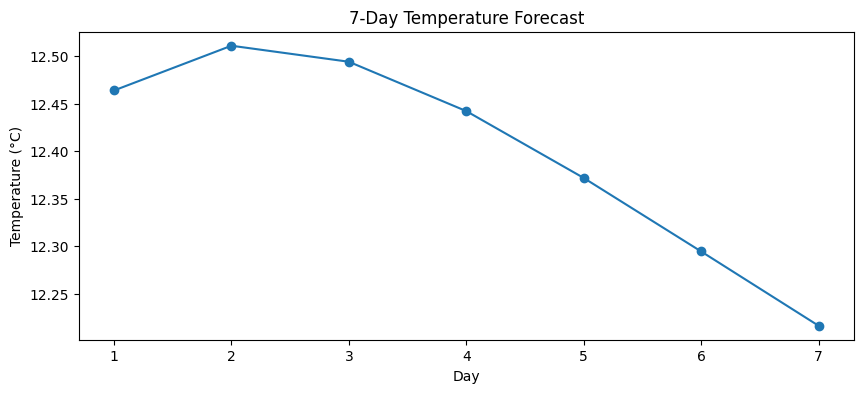

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(range(1,8), forecast, marker='o')
plt.title('7-Day Temperature Forecast')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.show()

### ***Using Linear Regressions***

 Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import math

Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url, parse_dates=['Date'])

df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


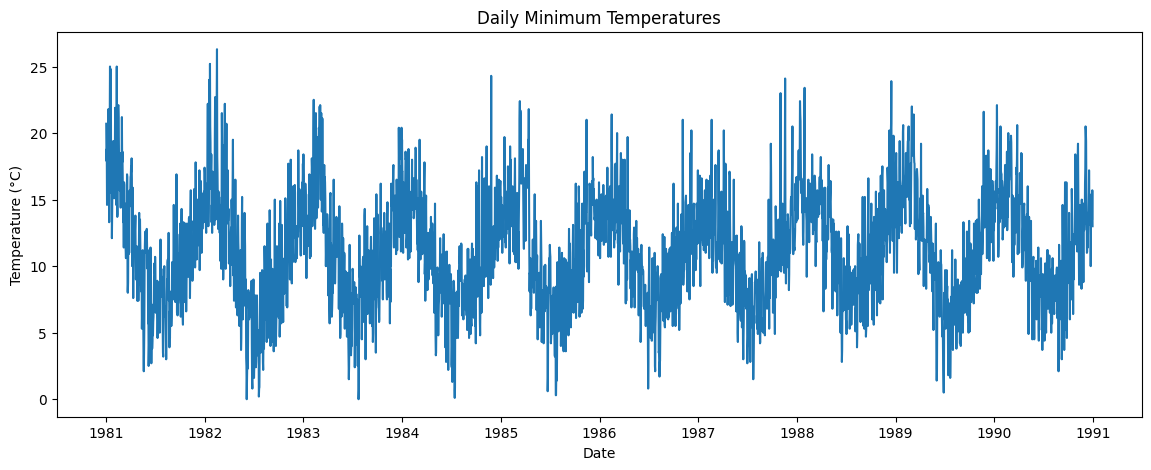

In [3]:
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Temp'])
plt.title('Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

Data Preparation

In [4]:
data = df['Temp'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

Create Time-Series Windows

In [5]:
def create_dataset(dataset, time_step=30):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i+time_step, 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 30

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

Linear Regression Model

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Predictions

In [7]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse scaling
train_predict = scaler.inverse_transform(train_predict.reshape(-1,1))
y_train_orig = scaler.inverse_transform(y_train.reshape(-1,1))

test_predict = scaler.inverse_transform(test_predict.reshape(-1,1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1,1))

RMSE Evaluation

In [8]:
train_rmse = math.sqrt(mean_squared_error(y_train_orig, train_predict))
test_rmse = math.sqrt(mean_squared_error(y_test_orig, test_predict))

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Train RMSE: 2.44
Test RMSE: 2.21


Visualization

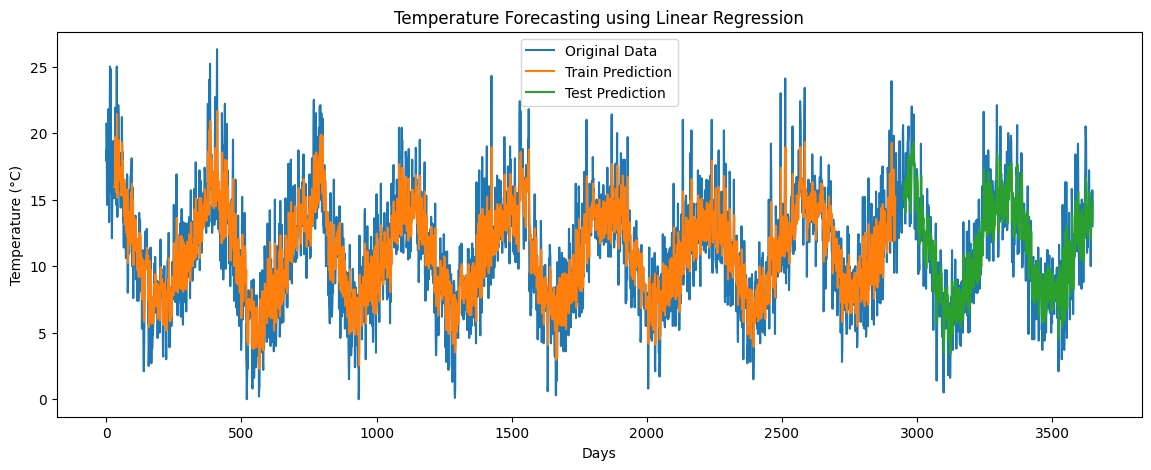

In [9]:
train_plot = np.empty_like(data)
train_plot[:] = np.nan
train_plot[time_step:len(train_predict)+time_step] = train_predict

test_plot = np.empty_like(data)
test_plot[:] = np.nan
test_plot[len(train_predict)+(time_step*2):len(data)] = test_predict

plt.figure(figsize=(14,5))
plt.plot(scaler.inverse_transform(scaled_data), label='Original Data')
plt.plot(train_plot, label='Train Prediction')
plt.plot(test_plot, label='Test Prediction')
plt.title('Temperature Forecasting using Linear Regression')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

7-Day Forecast (Recursive Prediction)

In [10]:
last_sequence = test_data[-time_step:].reshape(1, -1)
forecast_scaled = []

for _ in range(7):
    next_pred = model.predict(last_sequence)[0]
    forecast_scaled.append(next_pred)
    last_sequence = np.roll(last_sequence, -1)
    last_sequence[0, -1] = next_pred

forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1,1))

print("7-Day Forecast:")
print(forecast.flatten())

7-Day Forecast:
[13.24121191 13.75320591 13.9009042  13.69185088 13.51316451 13.3784435
 13.35814622]


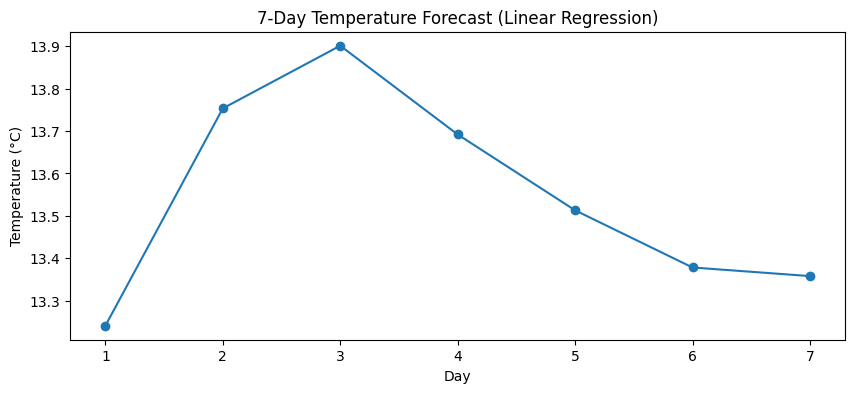

In [11]:
plt.figure(figsize=(10,4))
plt.plot(range(1,8), forecast, marker='o')
plt.title('7-Day Temperature Forecast (Linear Regression)')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.show()

### ***Using RandomForest***

Imports

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import math

Load Dataset

In [19]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url, parse_dates=['Date'])

df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


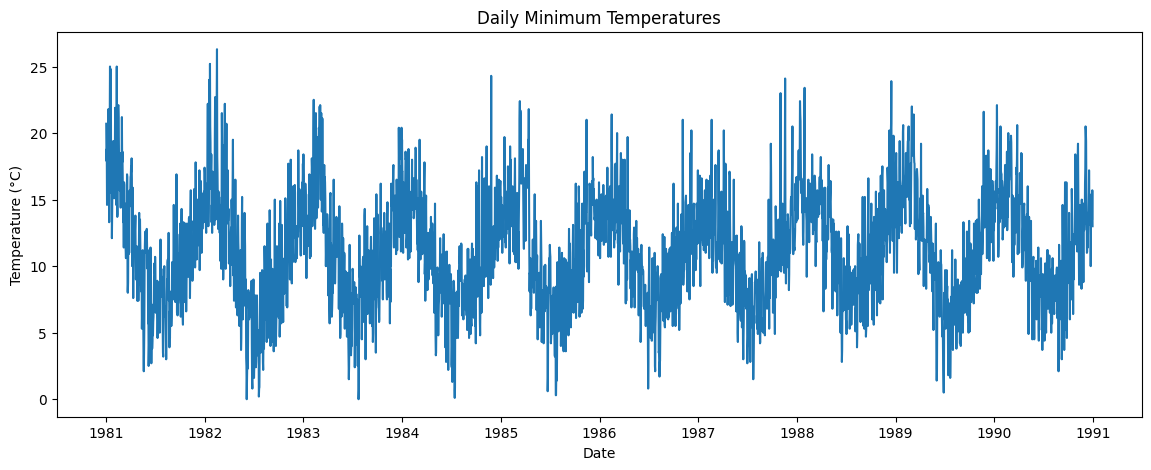

In [20]:
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Temp'])
plt.title('Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

Scaling & Train-Test Split

In [21]:
data = df['Temp'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

Create Sliding Windows

In [22]:
def create_dataset(dataset, time_step=30):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i+time_step, 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 30

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

Train Random Forest Model

In [23]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

Predictions

In [24]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse scaling
train_predict = scaler.inverse_transform(train_predict.reshape(-1,1))
y_train_orig = scaler.inverse_transform(y_train.reshape(-1,1))

test_predict = scaler.inverse_transform(test_predict.reshape(-1,1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1,1))

RMSE Evaluation

In [25]:
train_rmse = math.sqrt(mean_squared_error(y_train_orig, train_predict))
test_rmse = math.sqrt(mean_squared_error(y_test_orig, test_predict))

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Train RMSE: 1.48
Test RMSE: 2.17


Visualization

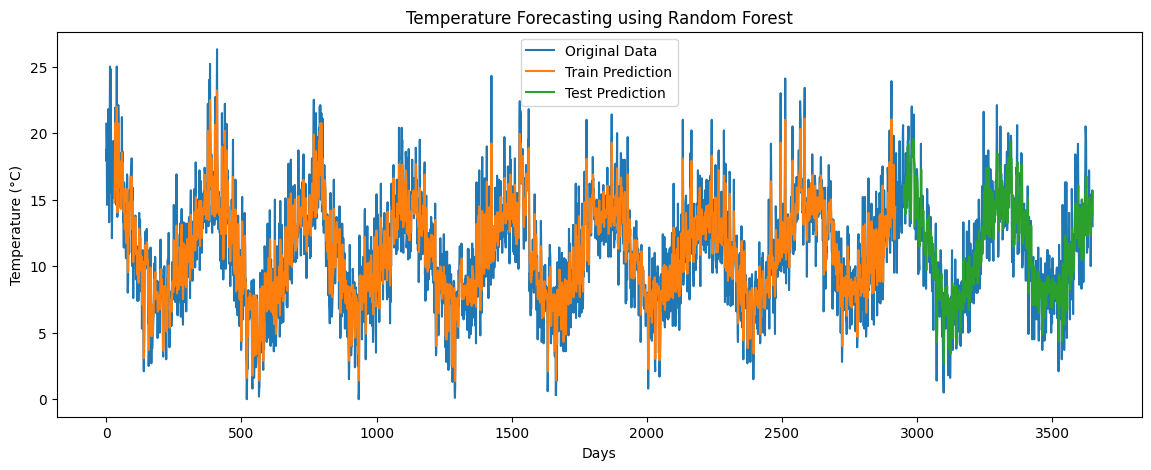

In [26]:
train_plot = np.empty_like(data)
train_plot[:] = np.nan
train_plot[time_step:len(train_predict)+time_step] = train_predict

test_plot = np.empty_like(data)
test_plot[:] = np.nan
test_plot[len(train_predict)+(time_step*2):len(data)] = test_predict

plt.figure(figsize=(14,5))
plt.plot(scaler.inverse_transform(scaled_data), label='Original Data')
plt.plot(train_plot, label='Train Prediction')
plt.plot(test_plot, label='Test Prediction')
plt.title('Temperature Forecasting using Random Forest')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

7-Day Forecast (Recursive Strategy)

In [27]:
last_sequence = test_data[-time_step:].reshape(1, -1)
forecast_scaled = []

for _ in range(7):
    next_pred = model.predict(last_sequence)[0]
    forecast_scaled.append(next_pred)
    last_sequence = np.roll(last_sequence, -1)
    last_sequence[0, -1] = next_pred

forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1,1))

print("7-Day Forecast:")
print(forecast.flatten())

7-Day Forecast:
[12.86661232 13.21935629 13.9117701  14.28045397 14.13111677 13.74041484
 13.96297865]


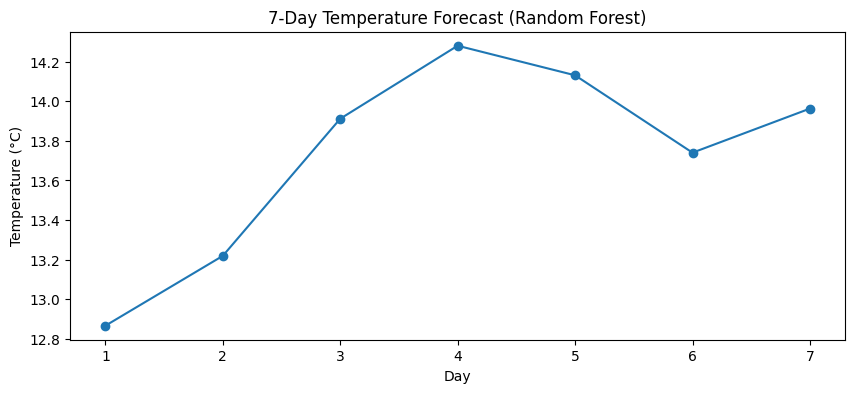

In [28]:
plt.figure(figsize=(10,4))
plt.plot(range(1,8), forecast, marker='o')
plt.title('7-Day Temperature Forecast (Random Forest)')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.show()

### ***Comparision***

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

Load Dataset

In [30]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url, parse_dates=['Date'])

data = df['Temp'].values.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

Create Time-Series Dataset

In [31]:
def create_dataset(dataset, time_step=30):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i+time_step, 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 30

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

1) Linear Regression

In [32]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

2. LSTM

In [33]:
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step,1)),
    Dropout(0.2),
    LSTM(50),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, verbose=0)

lstm_train_pred = lstm_model.predict(X_train_lstm)
lstm_test_pred = lstm_model.predict(X_test_lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


Random Forest

In [34]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

Inverse Scaling

In [35]:
def inverse_transform(y):
    return scaler.inverse_transform(y.reshape(-1,1))

y_train_orig = inverse_transform(y_train)
y_test_orig = inverse_transform(y_test)

lr_test_pred = inverse_transform(lr_test_pred)
rf_test_pred = inverse_transform(rf_test_pred)
lstm_test_pred = inverse_transform(lstm_test_pred)

RMSE Comparison

In [36]:
rmse_lr = math.sqrt(mean_squared_error(y_test_orig, lr_test_pred))
rmse_rf = math.sqrt(mean_squared_error(y_test_orig, rf_test_pred))
rmse_lstm = math.sqrt(mean_squared_error(y_test_orig, lstm_test_pred))

print("RMSE Comparison:")
print(f"Linear Regression : {rmse_lr:.2f}")
print(f"Random Forest     : {rmse_rf:.2f}")
print(f"LSTM              : {rmse_lstm:.2f}")

RMSE Comparison:
Linear Regression : 2.21
Random Forest     : 2.17
LSTM              : 2.24


Unified Comparison Plot

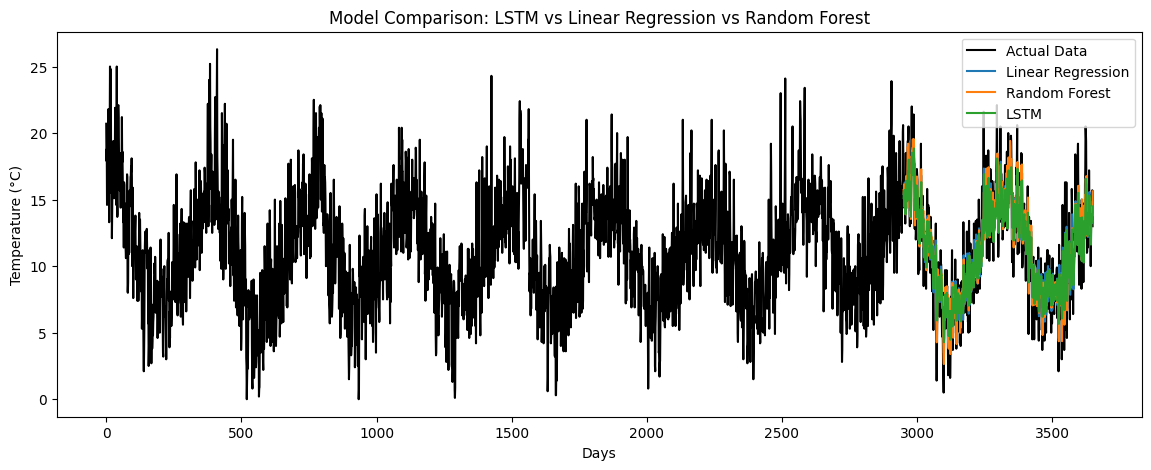

In [37]:
plot_lr = np.empty_like(data)
plot_rf = np.empty_like(data)
plot_lstm = np.empty_like(data)

plot_lr[:] = np.nan
plot_rf[:] = np.nan
plot_lstm[:] = np.nan

start = len(data) - len(lr_test_pred)

plot_lr[start:] = lr_test_pred
plot_rf[start:] = rf_test_pred
plot_lstm[start:] = lstm_test_pred

plt.figure(figsize=(14,5))
plt.plot(data, label='Actual Data', color='black')
plt.plot(plot_lr, label='Linear Regression')
plt.plot(plot_rf, label='Random Forest')
plt.plot(plot_lstm, label='LSTM')

plt.title('Model Comparison: LSTM vs Linear Regression vs Random Forest')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

Unified Comparison Scatter Plot

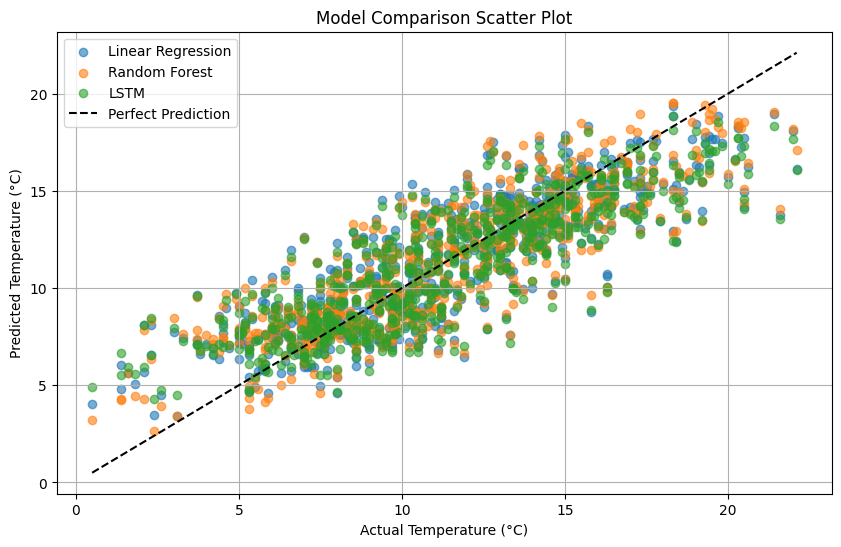

In [38]:
plt.figure(figsize=(10,6))

# Scatter plots
plt.scatter(y_test_orig, lr_test_pred, alpha=0.6, label='Linear Regression')
plt.scatter(y_test_orig, rf_test_pred, alpha=0.6, label='Random Forest')
plt.scatter(y_test_orig, lstm_test_pred, alpha=0.6, label='LSTM')

# Ideal prediction line (y = x)
min_val = y_test_orig.min()
max_val = y_test_orig.max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')

plt.title('Model Comparison Scatter Plot')
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

Generate 7-Day Forecasts

In [39]:
forecast_days = 7

# ----- Linear Regression -----
lr_input = test_data[-time_step:].reshape(1, -1)
lr_forecast = []

for _ in range(forecast_days):
    pred = lr_model.predict(lr_input)[0]
    lr_forecast.append(pred)
    lr_input = np.roll(lr_input, -1)
    lr_input[0, -1] = pred

# ----- Random Forest -----
rf_input = test_data[-time_step:].reshape(1, -1)
rf_forecast = []

for _ in range(forecast_days):
    pred = rf_model.predict(rf_input)[0]
    rf_forecast.append(pred)
    rf_input = np.roll(rf_input, -1)
    rf_input[0, -1] = pred

# ----- LSTM -----
lstm_input = test_data[-time_step:].reshape(1, time_step, 1)
lstm_forecast = []

for _ in range(forecast_days):
    pred = lstm_model.predict(lstm_input, verbose=0)[0][0]
    lstm_forecast.append(pred)
    lstm_input = np.roll(lstm_input, -1, axis=1)
    lstm_input[0, -1, 0] = pred

Inverse Scaling

In [40]:
lr_forecast = scaler.inverse_transform(np.array(lr_forecast).reshape(-1,1))
rf_forecast = scaler.inverse_transform(np.array(rf_forecast).reshape(-1,1))
lstm_forecast = scaler.inverse_transform(np.array(lstm_forecast).reshape(-1,1))

7-Day Forecast Comparison Plot

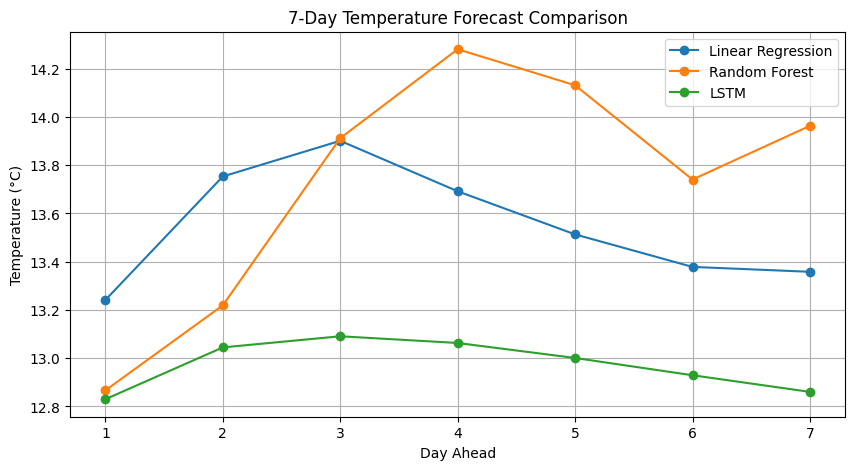

In [41]:
days = range(1, forecast_days + 1)

plt.figure(figsize=(10,5))
plt.plot(days, lr_forecast, marker='o', label='Linear Regression')
plt.plot(days, rf_forecast, marker='o', label='Random Forest')
plt.plot(days, lstm_forecast, marker='o', label='LSTM')

plt.title('7-Day Temperature Forecast Comparison')
plt.xlabel('Day Ahead')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()